# AI4I 2020 Predictive Maintenance Dataset 분석 노트북

**AI4I 2020 Predictive Maintenance Dataset**을 사용해 예지보전 PoC 관점의 분석을 수행

## 포함 내용
- 전처리
- class imbalance 대응
- XGBoost / LightGBM baseline
- PR-AUC, Recall 중심 평가
- SHAP / Feature Importance
- PoC 보고서형 해석

## 1. 문제 정의

AI4I 2020은 산업 설비 예지보전 상황을 모사한 공개 데이터입니다.  
이 노트북에서는 다음과 같은 질문을 다룹니다.

> 센서 및 운전 조건 정보를 바탕으로 **Machine failure**를 조기에 잘 구분할 수 있는가?

PoC 관점에서 중요한 것은 단순 accuracy보다:
- **Recall**: 실제 고장을 얼마나 놓치지 않는가
- **PR-AUC**: 불균형 데이터에서 양성 클래스(고장)를 얼마나 잘 구분하는가

입니다.

즉, 이 노트북은 **고장을 놓치지 않는 방향**을 더 중요하게 봅니다.

In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap

## 2. 경로 및 기본 설정

In [23]:
RANDOM_STATE = 42

DATA_PATH = Path("../data/ai4i2020.csv")
TARGET_COL = "Machine failure"

print("DATA_PATH:", DATA_PATH.resolve())
print("Exists:", DATA_PATH.exists())

DATA_PATH: /Users/joiy/Dropbox/Biz/wishket/202604_Predictive_Maintenance/predictive_maintenance_analysis/data_analysis/AI4I_2020_Predictive_Maintenance_Data_Analysis/data/ai4i2020.csv
Exists: True


## 3. 데이터 로드

In [24]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"파일을 찾을 수 없습니다: {DATA_PATH}\n"
        "CSV 파일을 data/raw/ai4i/ 폴더에 넣거나 DATA_PATH를 수정하세요."
    )

df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
df.head()

shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 4. 기본 구조 확인

In [25]:
print("columns:")
print(df.columns.tolist())

print("\ndtypes:")
print(df.dtypes)

columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

dtypes:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [26]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

결측치가 없으면 빈 결과가 나옵니다.  
AI4I는 보통 결측치 없는 공개 예제 데이터로 많이 사용됩니다.

## 5. 타깃 분포 확인

In [27]:
target_counts = df[TARGET_COL].value_counts().sort_index()
target_ratio = df[TARGET_COL].value_counts(normalize=True).sort_index()

print("target counts:")
print(target_counts)

print("\ntarget ratio:")
print(target_ratio)

target counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64

target ratio:
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


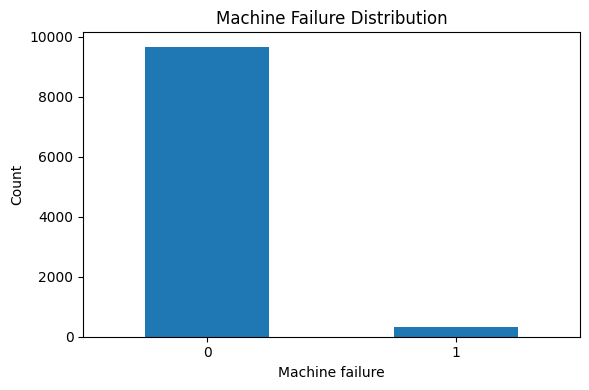

In [28]:
plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Machine Failure Distribution")
plt.xlabel("Machine failure")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 해석
AI4I는 일반적으로 **고장(1)이 적고 정상(0)이 많은 불균형 데이터**입니다.  
따라서 accuracy만 보면 성능이 과대평가될 수 있습니다.

## 6. 세부 failure type 확인

In [29]:
failure_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
existing_failure_cols = [c for c in failure_cols if c in df.columns]
existing_failure_cols

['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

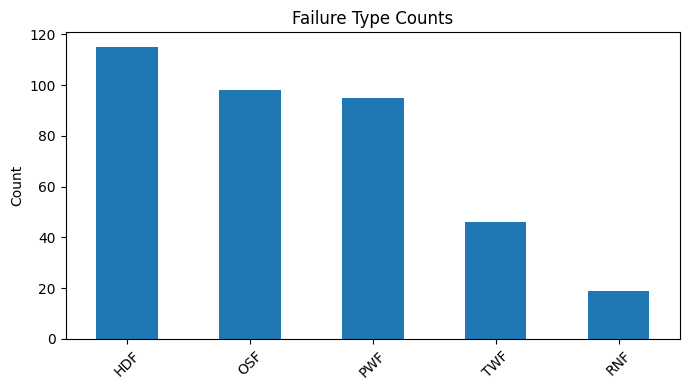

In [30]:
if existing_failure_cols:
    failure_summary = df[existing_failure_cols].sum().sort_values(ascending=False)
    display(failure_summary)

    plt.figure(figsize=(7, 4))
    failure_summary.plot(kind="bar")
    plt.title("Failure Type Counts")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 7. 전처리

### 처리 전략
- 식별자 컬럼 제거: `UDI`, `Product ID`
- 범주형 변수 인코딩: `Type`
- 타깃과 세부 failure columns 분리
- 모델 입력용 feature matrix 구성

In [31]:
df_model = df.copy()

drop_cols = ["UDI", "Product ID"]
drop_cols = [c for c in drop_cols if c in df_model.columns]
df_model = df_model.drop(columns=drop_cols)

aux_failure_cols = [c for c in ["TWF", "HDF", "PWF", "OSF", "RNF"] if c in df_model.columns]
feature_drop_cols = [TARGET_COL] + aux_failure_cols

if "Type" in df_model.columns:
    df_model = pd.get_dummies(df_model, columns=["Type"], drop_first=True)

X = df_model.drop(columns=feature_drop_cols)
y = df_model[TARGET_COL].copy()

print("X shape:", X.shape)
print("y mean:", y.mean())
X.head()

X shape: (10000, 7)
y mean: 0.0339


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False


## 8. 대표 feature 분포 확인

In [32]:
candidate_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]
candidate_cols = [c for c in candidate_cols if c in df.columns]
candidate_cols

['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]']

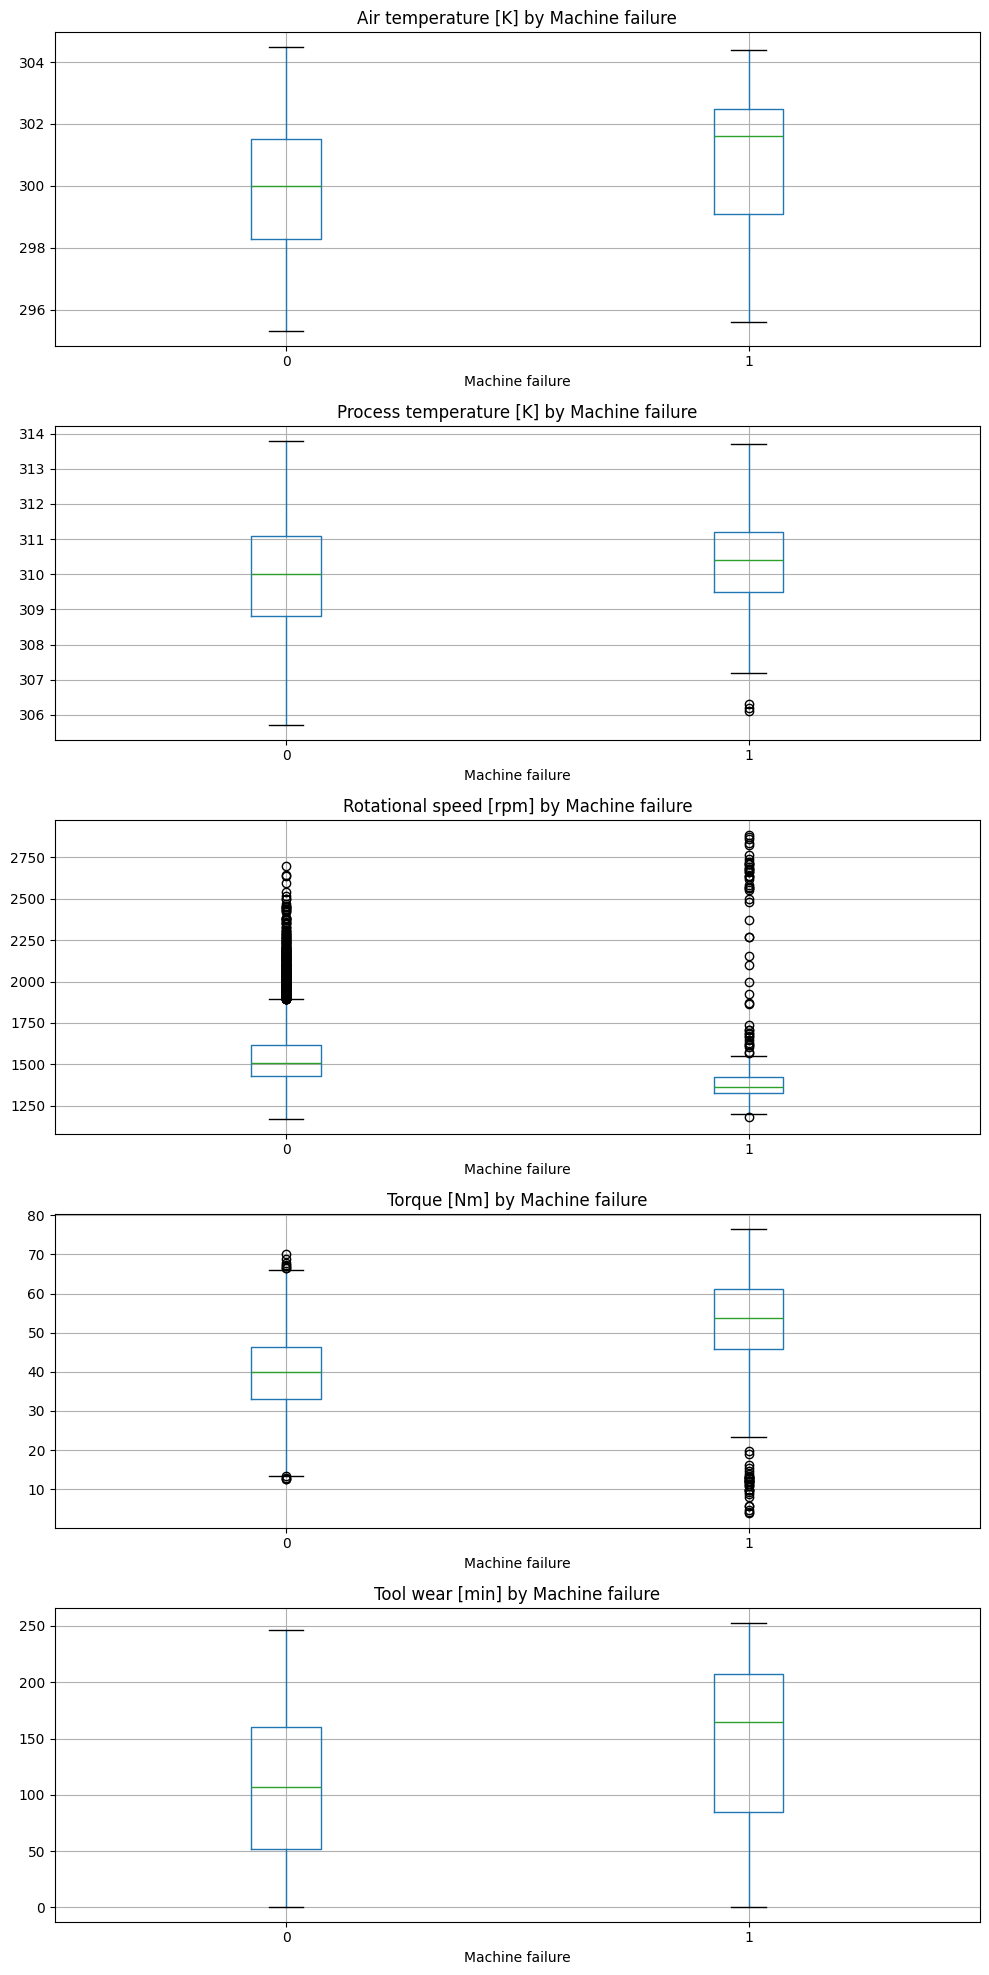

In [33]:
if candidate_cols:
    fig, axes = plt.subplots(len(candidate_cols), 1, figsize=(10, 4 * len(candidate_cols)))
    if len(candidate_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, candidate_cols):
        df.boxplot(column=col, by=TARGET_COL, ax=ax)
        ax.set_title(f"{col} by {TARGET_COL}")
        ax.set_xlabel(TARGET_COL)

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

## 9. train/test split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("positive ratio - train:", y_train.mean())
print("positive ratio - test:", y_test.mean())

X_train: (8000, 7)
X_test: (2000, 7)
positive ratio - train: 0.033875
positive ratio - test: 0.034


In [35]:
def clean_feature_names(df):
    df = df.copy()
    df.columns = [
        str(c).replace("[", "_")
              .replace("]", "")
              .replace("<", "_lt_")
              .replace(" ", "_")
              .replace("/", "_")
        for c in df.columns
    ]
    return df

X_train_xgb = clean_feature_names(X_train)
X_test_xgb = clean_feature_names(X_test)

print(X_train_xgb.columns.tolist())

['Air_temperature__K', 'Process_temperature__K', 'Rotational_speed__rpm', 'Torque__Nm', 'Tool_wear__min', 'Type_L', 'Type_M']


## 10. class imbalance 대응 전략

이 노트북에서는 간단하고 실무적인 baseline으로 다음을 사용합니다.

- **XGBoost**: `scale_pos_weight`
- **LightGBM**: `class_weight='balanced'`

즉, 소수 클래스(고장)에 더 민감하도록 학습시킵니다.

In [36]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("negative:", neg)
print("positive:", pos)
print("scale_pos_weight:", round(scale_pos_weight, 4))

negative: 7729
positive: 271
scale_pos_weight: 28.5203


In [37]:
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {cls: w for cls, w in zip(classes, weights)}
class_weight_dict

{0: 0.51753137533963, 1: 14.760147601476016}

## 11. 평가 함수

PoC에서는 accuracy보다 다음을 강조합니다.

- **Recall**: 실제 고장을 얼마나 놓치지 않았는가
- **PR-AUC**: 불균형 데이터에서 양성 클래스 품질

In [38]:
def evaluate_binary_model(y_true, y_pred, y_prob):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_prob),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }

def threshold_report(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.1, 0.95, 0.05)

    rows = []
    for th in thresholds:
        pred = (y_prob >= th).astype(int)
        rows.append({
            "threshold": round(float(th), 2),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
        })
    return pd.DataFrame(rows)

## 12. XGBoost baseline

In [39]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train_xgb, y_train)

xgb_pred = xgb_model.predict(X_test_xgb)
xgb_prob = xgb_model.predict_proba(X_test_xgb)[:, 1]

xgb_result = evaluate_binary_model(y_test, xgb_pred, xgb_prob)
pd.Series(xgb_result)

precision    0.620690
recall       0.794118
f1           0.696774
pr_auc       0.825934
roc_auc      0.972073
dtype: float64

In [40]:
print("=== XGBoost Classification Report ===")
print(classification_report(y_test, xgb_pred, zero_division=0))

=== XGBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.62      0.79      0.70        68

    accuracy                           0.98      2000
   macro avg       0.81      0.89      0.84      2000
weighted avg       0.98      0.98      0.98      2000



## 13. LightGBM baseline

In [42]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

lgbm_model.fit(X_train_xgb, y_train)

lgbm_pred = lgbm_model.predict(X_test)
lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]

lgbm_result = evaluate_binary_model(y_test, lgbm_pred, lgbm_prob)
pd.Series(lgbm_result)

[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011904 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 927
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


precision    0.791045
recall       0.779412
f1           0.785185
pr_auc       0.850090
roc_auc      0.972324
dtype: float64

In [43]:
print("=== LightGBM Classification Report ===")
print(classification_report(y_test, lgbm_pred, zero_division=0))

=== LightGBM Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.79      0.78      0.79        68

    accuracy                           0.99      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.99      0.99      0.99      2000



## 14. baseline 결과 비교

In [44]:
results_df = pd.DataFrame({
    "xgboost": xgb_result,
    "lightgbm": lgbm_result
}).T

results_df.sort_values(by=["pr_auc", "recall"], ascending=False)

,precision,recall,f1,pr_auc,roc_auc
lightgbm,0.791045,0.779412,0.785185,0.850090,0.972324
xgboost,0.620690,0.794118,0.696774,0.825934,0.972073


### 해석 포인트
- **PR-AUC**가 높은 모델은 고장 클래스를 더 잘 분리한 모델로 볼 수 있습니다.
- **Recall**이 높은 모델은 실제 고장을 덜 놓치는 방향입니다.
- 실제 예지보전 PoC에서는 종종 precision보다 recall을 더 중시합니다.

## 15. Confusion Matrix

Best model: lightgbm


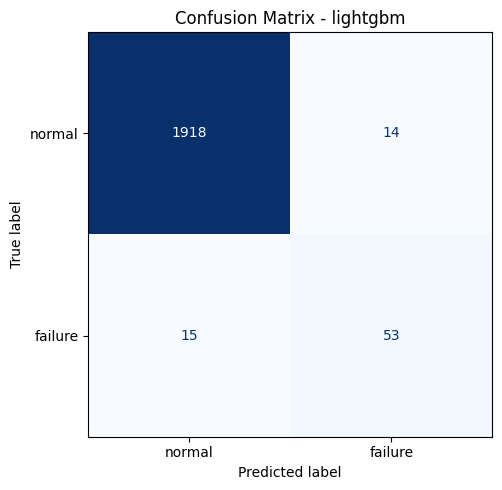

In [45]:
best_model_name = results_df.sort_values(by=["pr_auc", "recall"], ascending=False).index[0]
best_model = xgb_model if best_model_name == "xgboost" else lgbm_model
best_prob = xgb_prob if best_model_name == "xgboost" else lgbm_prob
best_pred = xgb_pred if best_model_name == "xgboost" else lgbm_pred

print("Best model:", best_model_name)

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["normal", "failure"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

## 16. Precision-Recall Curve

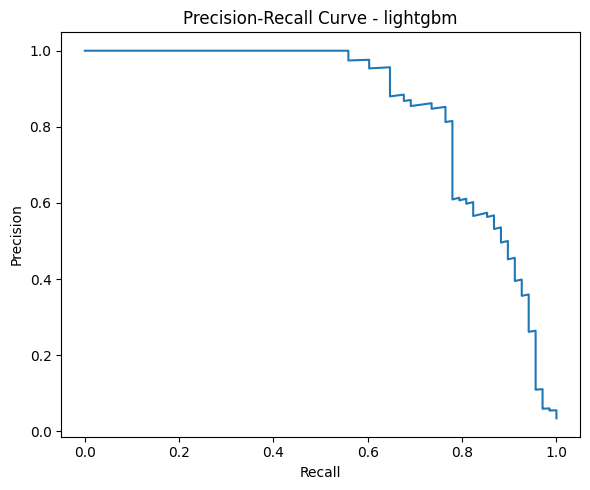

In [46]:
precision, recall, thresholds = precision_recall_curve(y_test, best_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.title(f"Precision-Recall Curve - {best_model_name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()

## 17. Threshold tuning

기본 0.5 threshold가 항상 최선은 아닙니다.  
예지보전에서는 **고장을 덜 놓치기 위해 threshold를 낮춰 recall을 높이는 전략**이 종종 유효합니다.

In [47]:
th_df = threshold_report(y_test, best_prob)
th_df

,threshold,precision,recall,f1
0,0.10,0.546296,0.867647,0.670455
1,0.15,0.568627,0.852941,0.682353
2,0.20,0.589474,0.823529,0.687117
3,0.25,0.611111,0.808824,0.696203
4,0.30,0.654321,0.779412,0.711409
5,0.35,0.670886,0.779412,0.721088
6,0.40,0.716216,0.779412,0.746479
7,0.45,0.716216,0.779412,0.746479
8,0.50,0.791045,0.779412,0.785185
9,0.55,0.812500,0.764706,0.787879


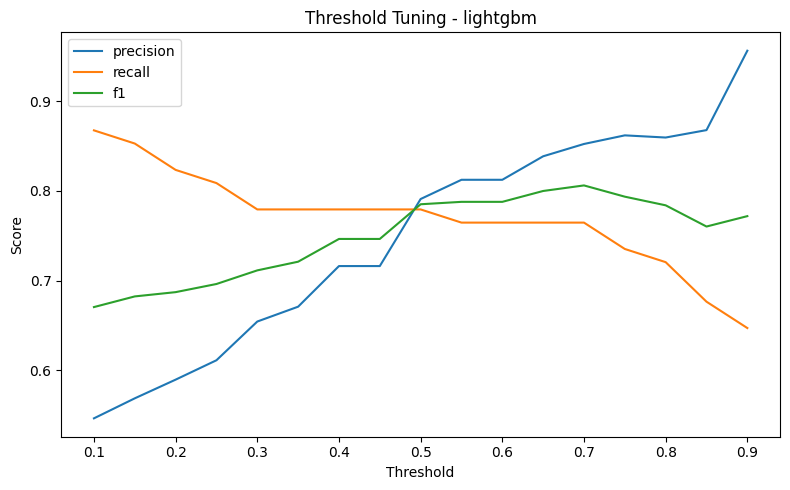

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(th_df["threshold"], th_df["precision"], label="precision")
plt.plot(th_df["threshold"], th_df["recall"], label="recall")
plt.plot(th_df["threshold"], th_df["f1"], label="f1")
plt.title(f"Threshold Tuning - {best_model_name}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
selected_threshold = 0.30
selected_pred = (best_prob >= selected_threshold).astype(int)

selected_metrics = {
    "precision": precision_score(y_test, selected_pred, zero_division=0),
    "recall": recall_score(y_test, selected_pred, zero_division=0),
    "f1": f1_score(y_test, selected_pred, zero_division=0),
    "pr_auc": average_precision_score(y_test, best_prob),
}
pd.Series(selected_metrics, name=f"threshold={selected_threshold}")

precision    0.654321
recall       0.779412
f1           0.711409
pr_auc       0.850090
Name: threshold=0.3, dtype: float64

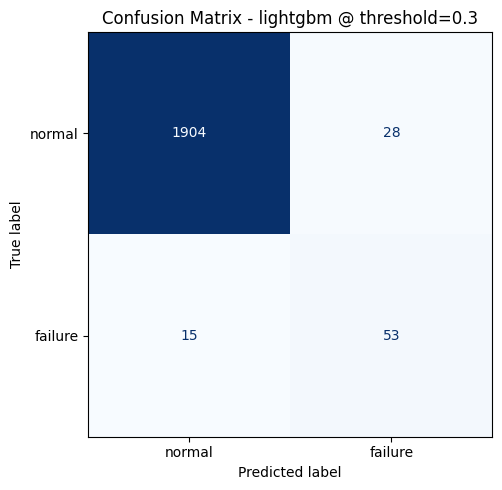

In [50]:
cm = confusion_matrix(y_test, selected_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["normal", "failure"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix - {best_model_name} @ threshold={selected_threshold}")
plt.tight_layout()
plt.show()

## 18. Feature Importance

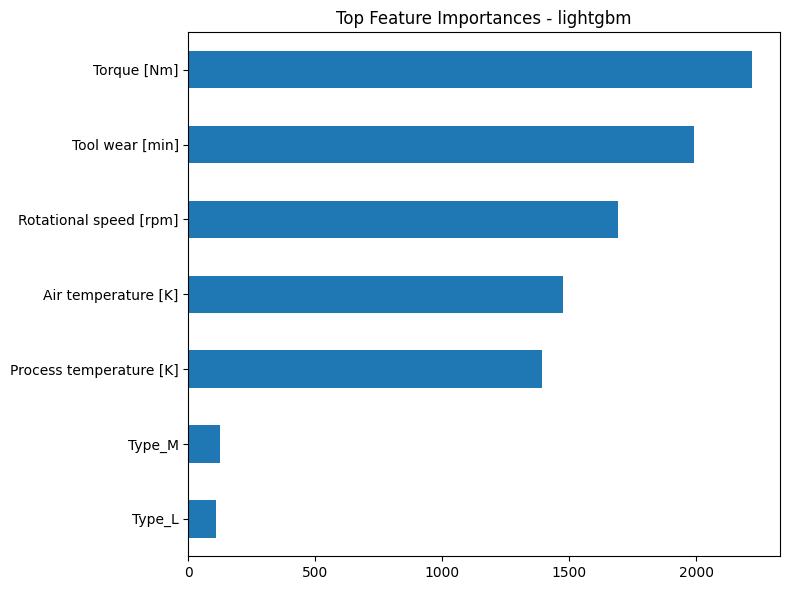

In [51]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

    plt.figure(figsize=(8, 6))
    importances.head(15).sort_values().plot(kind="barh")
    plt.title(f"Top Feature Importances - {best_model_name}")
    plt.tight_layout()
    plt.show()

    importances.head(15)

## 19. SHAP 해석

best_model_name: lightgbm
best_model_type: <class 'lightgbm.sklearn.LGBMClassifier'>


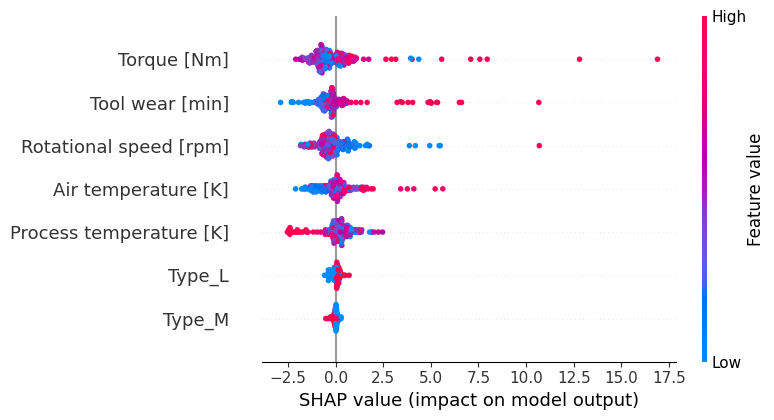

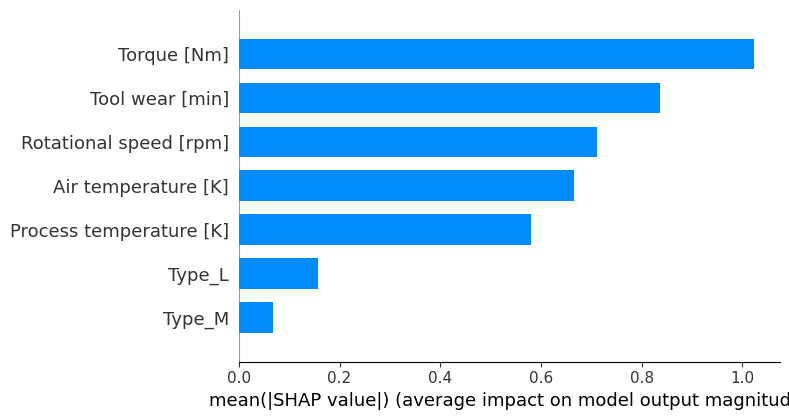

In [57]:
import shap

print("best_model_name:", best_model_name)
print("best_model_type:", type(best_model))

X_shap = X_test.iloc[:200].copy()

explainer = shap.TreeExplainer(
    best_model,
    feature_perturbation="tree_path_dependent",
    model_output="raw"
)

shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, max_display=15)
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=15)

## 20. PoC 보고서형 해석

### Executive Summary
- AI4I 2020 데이터를 기반으로 `Machine failure` 이진 분류 baseline을 구축했다.
- 데이터는 고장 클래스 비율이 낮은 **불균형 구조**이므로 accuracy보다 **PR-AUC, Recall**을 중심으로 평가했다.
- XGBoost와 LightGBM을 비교한 결과, 선택된 best baseline은 고장 클래스 분리에 대해 의미 있는 PR-AUC를 보였다.
- threshold tuning을 통해 recall을 더 높이는 방향의 운영 전략도 검토했다.
- feature importance / SHAP 해석 결과, 회전 속도, 토크, 공정 온도, 공구 마모 등 일부 변수들이 failure 예측에 유의미하게 기여하는 경향을 보였다.

### Business / Operational Interpretation
- 예지보전 PoC 관점에서는 “고장을 얼마나 잘 찾는가”가 중요하므로 recall 중심 운영이 타당하다.
- 다만 recall을 높이면 false positive가 증가할 수 있어, 실제 적용 시에는 경보 비용과 정비 비용 간 균형이 필요하다.
- 따라서 운영 단계에서는 **threshold tuning**, **경보 등급화**, **도메인 전문가 검토**가 함께 필요하다.

### Technical Interpretation
- class imbalance 대응 없이 학습하면 고장 클래스 탐지가 약해질 수 있다.
- 트리 기반 부스팅 모델은 tabular industrial data에서 baseline으로 유효하다.
- SHAP/feature importance를 통해 예측 근거를 설명할 수 있어, PoC 보고서 및 현업 커뮤니케이션에 유리하다.

### Limitations
- AI4I는 실제 플랜트 센서 데이터가 아니라 synthetic benchmark 성격을 가진 공개 데이터다.
- 시간 순서 기반 조기경보(lead time) 평가 대신 row-level classification 중심이다.
- 실제 현장 적용 시에는 설비별 운전 조건, 센서 노이즈, 이벤트 로그 정합성 등을 추가 반영해야 한다.

### Next Steps
1. 실제 설비 데이터에 동일 파이프라인 적용
2. 시계열 window 기반 feature engineering 추가
3. anomaly detection baseline 추가
4. event-level / lead-time 평가 설계
5. 현장 도메인 전문가와 함께 threshold 및 경보 정책 구체화